## Imports and loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/creditcard.csv")
df.shape

(284807, 31)

## First rows

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Column types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## Summary statistics

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Missing values and class balance

In [5]:
print("Missing values:", df.isna().sum().sum())
print()
print(df["Class"].value_counts())
print()
print(df["Class"].value_counts(normalize=True))

Missing values: 0

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## Notes
- **Size:** the dataset has 284807 rows and 31 columns.
- **Missing values:** 0
- **Fraud rate:** 0.17% of transactions are fraud (492 out of 284315).
- **Anonymized columns:** V1–V28 (PCA-transformed, so we can't interpret them directly).
- **Understandable columns:** Time (seconds since first transaction), Amount (transaction value), Class (0 = normal, 1 = fraud).

## Find the duplicates

In [6]:
print("Rows before cleaning:", len(df))
print("Duplicate rows:", df.duplicated().sum())

Rows before cleaning: 284807
Duplicate rows: 1081


## Removing the duplicates

In [7]:
df = df.drop_duplicates().reset_index(drop=True)

print("Rows after cleaning:", len(df))
print(df["Class"].value_counts())

Rows after cleaning: 283726
Class
0    283253
1       473
Name: count, dtype: int64


## Look at Amount

In [8]:
print(df["Amount"].describe())
print()
print("Zero-amount rows:", (df["Amount"] == 0).sum())

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

Zero-amount rows: 1808


## Plot Amount before and after a log transform

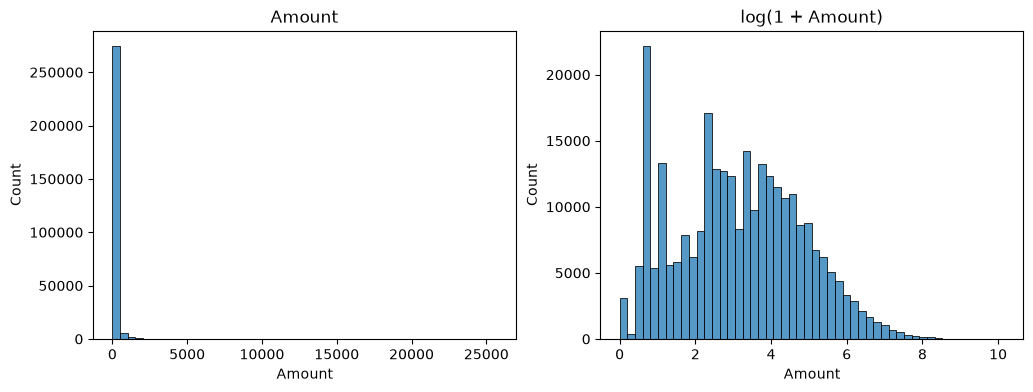

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Amount"], bins=50, ax=ax[0])
ax[0].set_title("Amount")

sns.histplot(np.log1p(df["Amount"]), bins=50, ax=ax[1])
ax[1].set_title("log(1 + Amount)")

plt.show()

## Adding Features

In [10]:
df["log_amount"] = np.log1p(df["Amount"])
df["hour"] = (df["Time"] // 3600) % 24

df[["Time", "hour", "Amount", "log_amount"]].head(10)

,Time,hour,Amount,log_amount
0,0.0,0.0,149.62,5.014760
1,0.0,0.0,2.69,1.305626
2,1.0,0.0,378.66,5.939276
3,1.0,0.0,123.50,4.824306
4,2.0,0.0,69.99,4.262539
5,2.0,0.0,3.67,1.541159
6,4.0,0.0,4.99,1.790091
7,7.0,0.0,40.80,3.732896
8,7.0,0.0,93.20,4.545420
9,9.0,0.0,3.68,1.543298


In [11]:
print("hour range:", df["hour"].min(), "to", df["hour"].max())
print(df.shape)

hour range: 0.0 to 23.0
(283726, 33)


## Cleaning decisions
- **Duplicates:** removed 1081 duplicate rows (19 frauds among them). Removing them before splitting prevents the same transaction from appearing in both train and test.
- **Amount:** heavily skewed (mean ≈ 88.472687, median ≈ 22.000000, max ≈ 25691.160000). I added `log_amount = log(1 + Amount)` to make it more balanced.
- **Zero-amount rows:** kept, because they're probably card verification checks, not errors, and some of them are fraud, so deleting them would throw away real signal.
- **hour:** `(Time // 3600) % 24`. It's approximate, because Time starts at the first transaction, not at midnight.
- **Scaling:** postponed so it can be fitted on training data only.

## How imbalanced is it ?

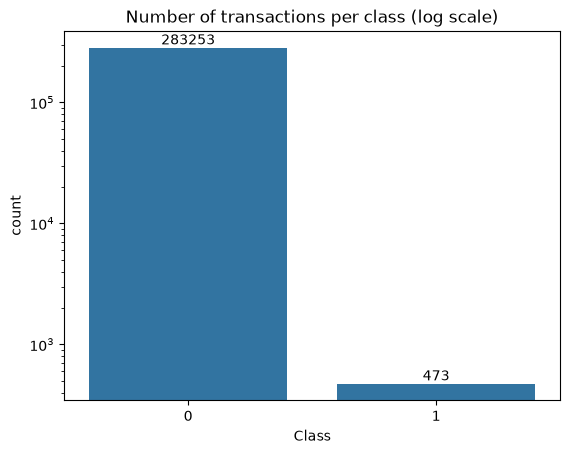

In [12]:
ax = sns.countplot(x="Class", data=df)
ax.bar_label(ax.containers[0])
plt.yscale("log")
plt.title("Number of transactions per class (log scale)")
plt.show()

Only 473 of 283,726 transactions (0.17%) are fraud, so there are about 600 normal transactions for each fraud.

## Do frauds have different amounts ?

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      283253.0   88.413575  250.379023  0.0  5.67  22.00   77.46  25691.16
1         473.0  123.871860  260.211041  0.0  1.00   9.82  105.89   2125.87


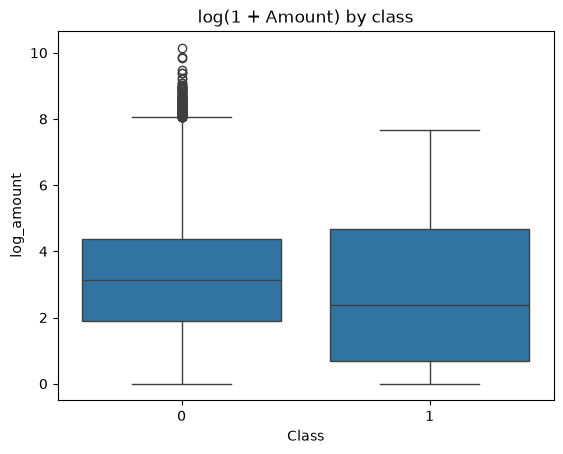

In [13]:
print(df.groupby("Class")["Amount"].describe())

sns.boxplot(x="Class", y="log_amount", data=df)
plt.title("log(1 + Amount) by class")
plt.show()

Fraud amounts are not clearly higher than normal ones: the median is lower, so Amount alone can't separate the classes.

## Does fraud depend on the hour ?

      frauds  transactions  fraud_rate
hour                                  
0          6          7647    0.000785
1         10          4208    0.002376
2         48          3308    0.014510
3         17          3487    0.004875
4         23          2204    0.010436
5         11          2988    0.003681
6          9          4082    0.002205
7         23          7233    0.003180
8          9         10232    0.000880
9         16         15767    0.001015
10         8         16548    0.000483
11        53         16781    0.003158
12        17         15378    0.001105
13        17         15323    0.001109
14        23         16520    0.001392
15        26         16374    0.001588
16        22         16396    0.001342
17        28         16130    0.001736
18        28         16959    0.001651
19        19         15566    0.001221
20        18         16705    0.001078
21        16         17629    0.000908
22         9         15378    0.000585
23        17         1088

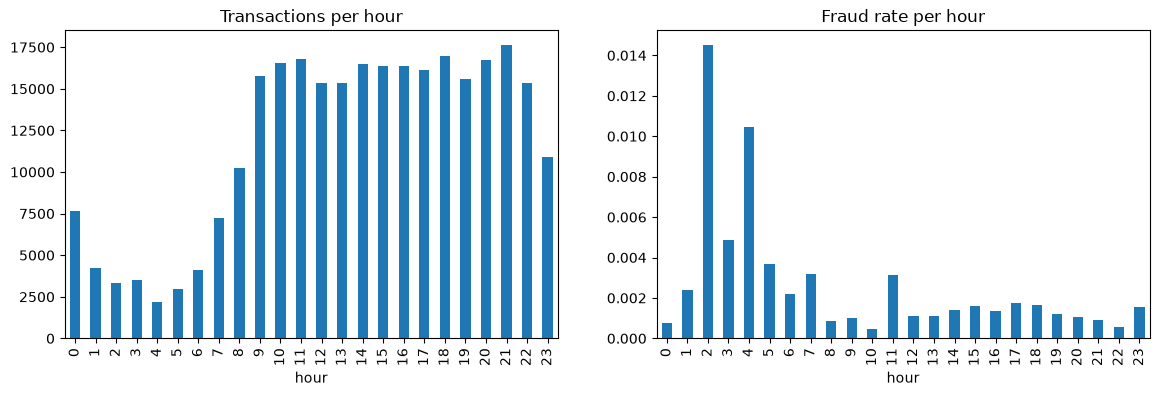

In [14]:
by_hour = df.groupby("hour")["Class"].agg(["sum", "count", "mean"])
by_hour.columns = ["frauds", "transactions", "fraud_rate"]
by_hour.index = by_hour.index.astype(int)
print(by_hour)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
by_hour["transactions"].plot(kind="bar", ax=ax[0], title="Transactions per hour")
by_hour["fraud_rate"].plot(kind="bar", ax=ax[1], title="Fraud rate per hour")
plt.show()

The fraud rate varies by hour and looks higher when overall activity is low, but with about 20 frauds per hour the pattern is noisy and should be treated as a hint, not a rule.

## Which V-features separate fraud from normal ?

In [15]:
corr = df.drop(columns=["Time"]).corr()["Class"].drop("Class")
top_corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
print(top_corr.head(10))

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64


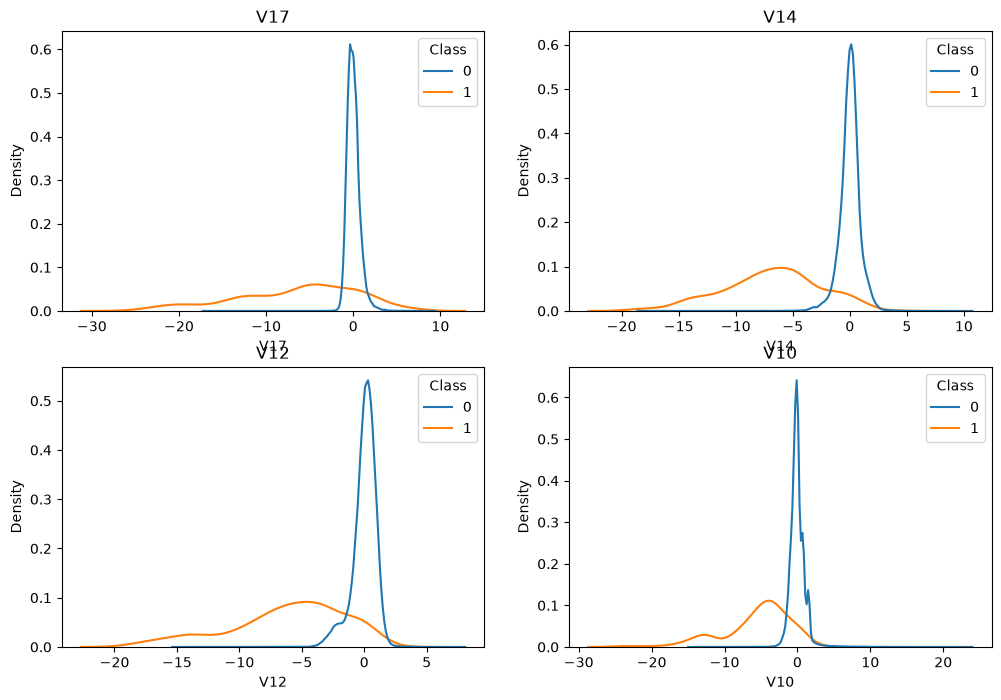

In [16]:
top = ["V17", "V14", "V12", "V10"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), top):
    sns.kdeplot(data=df, x=col, hue="Class", common_norm=False, ax=ax)
    ax.set_title(col)
plt.show()

V17, V14, V12 and V10 have clearly different distributions for frauds (shifted toward negative values), so they carry most of the signal a model can use.

## Findings

- **Imbalance:** 0.17% of transactions are fraud (473 out of 283253), so accuracy is a misleading metric.
- **Amount:** frauds have a lower median amount (9.82 vs 22.00), so amount alone doesn't identify fraud.
- **Time:** the fraud rate varies by hour, but with only 20 frauds the pattern is noisy.
- **Features:** V17, V14, V12 and V10 differ most between classes; frauds tend to have lower values.

## Train/Validation/Test split

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Class"])
y = df["Class"]

# Step A: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Step B: split the 30% in half -> 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s} {len(labels):>7} rows, {labels.sum():>4} frauds, {labels.mean():.4%} fraud")

train  198608 rows,  331 frauds, 0.1667% fraud
val     42559 rows,   71 frauds, 0.1668% fraud
test    42559 rows,   71 frauds, 0.1668% fraud


## Saving the split

In [18]:
from pathlib import Path

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

df.loc[X_train.index].to_csv(out_dir / "train.csv", index=False)
df.loc[X_val.index].to_csv(out_dir / "val.csv", index=False)
df.loc[X_test.index].to_csv(out_dir / "test.csv", index=False)

print("Saved:", [p.name for p in out_dir.iterdir()])

Saved: ['test.csv', 'train.csv', 'val.csv']


## Baseline: never predict fraud

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            average_precision_score, confusion_matrix)

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

pred = dummy.predict(X_val)
proba = dummy.predict_proba(X_val)[:, 1]

print("Accuracy :", round(accuracy_score(y_val, pred), 5))
print("Recall   :", recall_score(y_val, pred))
print("Precision:", precision_score(y_val, pred, zero_division=0))
print("PR-AUC   :", round(average_precision_score(y_val, proba), 5))
print()
print(confusion_matrix(y_val, pred))

Accuracy : 0.99833
Recall   : 0.0
Precision: 0.0
PR-AUC   : 0.00167

[[42488     0]
 [   71     0]]


## Split and baseline

- **Split:** 70/15/15 stratified. Train has 198608 rows (331 frauds), validation 42559 rows
  (71 frauds), test 42559 rows (71 frauds). Fraud rate is 0.167% in all three.
- **Test set:** saved but untouched until the final evaluation.
- **Baseline ("never fraud"):** accuracy 99.833%, recall 0, PR-AUC 0.00167. A model that never
  flags fraud catches 0 of the 71 frauds in validation, so accuracy is not a useful
  metric here. PR-AUC and recall are the ones to watch.